# Histology tile generation
Short walkthrough of unconditional and conditional histology tile synthesis.

In [6]:
import lazyslide as zs

wsi = zs.datasets.sample()

/data-nvme0/projects/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/io/_wsi.py:136: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


## Unconditional generation
Generate tiles without providing any input context.

In [4]:
images = zs.tl.image_generation()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Keyword arguments {'trust_remote_code': True} are not expected by CytoSynPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

This returns a list of PIL images; inspect the first sample.

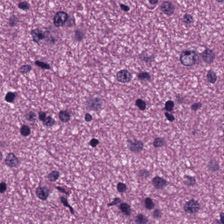

In [5]:
images[0]

## Conditional generation
Control synthesis using prior information such as tile features.

In [7]:
zs.tl.feature_extraction(wsi, "h0-mini")

Output()

Condition on the first tile feature vector.

In [8]:
images = zs.tl.image_generation(wsi, model="cytosyn", prompt_tiles=0)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Keyword arguments {'trust_remote_code': True} are not expected by CytoSynPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Compare the conditioning tile with generated samples.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

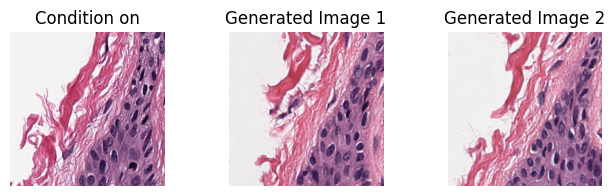

In [14]:
import matplotlib.pyplot as plt

for tile in wsi.iter.tile_images("tiles"):
    break

_, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(tile.image)
axes[0].set_title("Condition on")
axes[0].axis("off")

axes[1].imshow(images[0])
axes[1].set_title("Generated Image 1")
axes[1].axis("off")

axes[2].imshow(images[1])
axes[2].set_title("Generated Image 2")
axes[2].axis("off")